In [2]:
# 강사풀이

In [3]:
# https://github.com/pia222sk20/python/blob/main/machin-learing/telecome_churn.ipynb

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
pd.options.display.float_format = '{:.2f}'.format
import warnings
warnings.filterwarnings('ignore')

In [5]:
url = 'https://raw.githubusercontent.com/pia222sk20/python/refs/heads/main/data/tellecom.csv'
data = pd.read_csv(url)
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
data.shape

(7043, 21)

In [7]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


<Axes: >

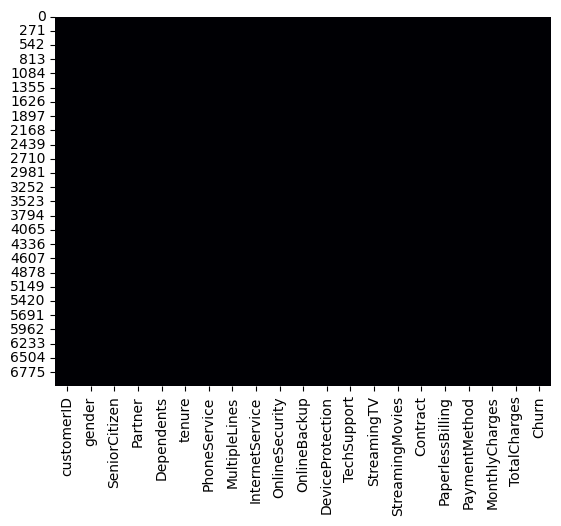

In [9]:
sns.heatmap(data.isnull(), cmap = 'magma', cbar=False)
# 결측치는 없는 것을 시각적으로 확인 : 히트맵

In [10]:
data.describe().T # .T를 붙이면 행과 열이 바뀐다. (전치행렬)

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.00,0.16,0.37,0.00,0.00,0.00,0.00,1.00
tenure,7043.00,32.37,24.56,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.00,64.76,30.09,18.25,35.50,70.35,89.85,118.75


In [11]:
'''
이 데이터셋에는 텍스트 형태의 데이터가 많은 특성(컬럼) 이 있으며, 이들은 아마도 범주형(feature) 일 가능성이 높습니다.
Total Charges 특성은 숫자형 값을 가지고 있지만, 현재 문자열(string) 형태로 저장되어 있습니다.
따라서, 먼저 이 열을 실수(float) 형으로 변환하겠습니다.
'''
# TotalCharges 데이터를 실수형으로 변환하기
# 해당 열 데이터 를 순환하며 공백 ( i는 len(i.split()) = 0 이렇게 나오면 공백, 공백으로 이루어진 문자열 데이터의 해당되는 인덱스를 조회할 수 있게한다. )
# 의 위치를 포함한 l1 리스트를 생성
l1 = [len(i.split()) for i in data['TotalCharges']]
# split() 이라고 괄호안에 아무것도 작성하지않고 수해시키면 “모든 종류의 공백 문자(whitespace)” 를 기준으로 문자열을 쪼갠다.
print(l1)

# 공백의 위치가 들어가있는 l1리스트를 통해 리스트 컴프리헨션으로 1, 중간에 공백이 없고 문자열데이터가 한개 있는 데이터, len(i,split()) = 1)
# 가 아닌 그외의 데이터들의 인덱스를 l2 리스트에 저장한다.
l2 = [i for i in range(len(l1)) if l1[i] != 1] # if v == 0 보다는 if l1[i] != 1 이렇게 하는게 더 포괄적으로 1이아닌 경우의 데이터들을 다 조회할 수 있겠다.
# l2 = [i for i, v in enumerate(l1) if v != 1] # 좀 더 간결하게 파이썬 다운 방식으로 수정
print('Index Positions with empty spaces : ',*l2)

# l2에 저장된 공백 데이터의 인덱스를 순환문으로 돌리면서 인덱스 1칸 앞에 있는 값으로 공백을 대체
for i in l2:
    data.loc[i,'TotalCharges'] = data.loc[(i-1),'TotalCharges']
# ffill을 사용 한, 공백 대체 방법
# data['TotalCharges'] = data['TotalCharges'].replace(' ', None).fillna(method='ffill')

# TotalCharges 내부의 데이터 들을 실수로 변환
data['TotalCharges'] = data['TotalCharges'].astype(float)

# customerID 열 삭제
data.drop(columns = ['customerID'], inplace = True)

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

In [12]:
# TotalCharges 열을 float(실수형) 으로 변환하는 과정에서
# 문자열을 숫자로 변환할 수 없다는 오류가 발생했습니다.

# 이 오류는 TotalCharges 열에 빈 문자열(공백 문자열, ' ') 이 포함되어 있기 때문입니다.
# 예를 들어, a = ' ' 과 같은 값은 문자열이지만 결측값(null) 으로 인식되지 않기 때문에,
# 결측값 시각화(예: 히트맵)에서는 표시되지 않았던 것입니다.

# 따라서, 우리는 TotalCharges 열의 각 원소를 문자열로 분리(split)하고,
# 그 길이가 1이 아닌(즉, 비어 있는) 요소들의 인덱스 번호를 추출했습니다.
# 이 인덱스 목록에 해당하는 값들은 이전 행의 값으로 대체(fill) 했습니다.

# 그 후 전체 TotalCharges 열을 astype(float)을 사용하여 실수형으로 변환했습니다.

# 마지막으로 고유 식별자 역할만 하는 customerID 열을 삭제하고,
# 데이터셋의 특성을 수치형(numerical) 과 범주형(categorical) 으로 구분했습니다.
# 범주형 특성들에 대해서는 레이블 인코딩(label encoding) 을 수행합니다.

In [13]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# LabelEncoder는 각 범주(category)를 0, 1, 2… 형태의 정수로 매핑합니다.
# 범주형 데이터를 숫자형 데이터로 바꾸기 : LabelEncoder().fit_transform(데이터)
# 숫자형 데이터를 범주형 데이터로 바꾸기 : LabelEncoder().inverse_transform(숫자데이터)

# 데이터 프레임 복사
df1 = data.copy(deep = True)

# 텍스트 데이터 목록 생성 : 수치형데이터가 아닌 컬럼들의 리스트 목록 생성
text_data_features = [i for i in list(data.columns) if i not in list(data.describe().columns)]

# LableEncoder로 df1의 텍스트 데이터 행들을 숫자형데이터로 변환 및 변환결과 조회
print('Label Encoder Transformation')
for i in text_data_features :
    df1[i] = le.fit_transform(df1[i])
    print(i,' : ',df1[i].unique(),' = ',le.inverse_transform(df1[i].unique()))

Label Encoder Transformation
gender  :  [0 1]  =  ['Female' 'Male']
Partner  :  [1 0]  =  ['Yes' 'No']
Dependents  :  [0 1]  =  ['No' 'Yes']
PhoneService  :  [0 1]  =  ['No' 'Yes']
MultipleLines  :  [1 0 2]  =  ['No phone service' 'No' 'Yes']
InternetService  :  [0 1 2]  =  ['DSL' 'Fiber optic' 'No']
OnlineSecurity  :  [0 2 1]  =  ['No' 'Yes' 'No internet service']
OnlineBackup  :  [2 0 1]  =  ['Yes' 'No' 'No internet service']
DeviceProtection  :  [0 2 1]  =  ['No' 'Yes' 'No internet service']
TechSupport  :  [0 2 1]  =  ['No' 'Yes' 'No internet service']
StreamingTV  :  [0 2 1]  =  ['No' 'Yes' 'No internet service']
StreamingMovies  :  [0 2 1]  =  ['No' 'Yes' 'No internet service']
Contract  :  [0 1 2]  =  ['Month-to-month' 'One year' 'Two year']
PaperlessBilling  :  [1 0]  =  ['Yes' 'No']
PaymentMethod  :  [2 3 0 1]  =  ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn  :  [0 1]  =  ['No' 'Yes']


In [14]:
df1.describe()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00
mean,0.50,0.16,0.48,0.30,32.37,0.90,0.94,0.87,0.79,0.91,0.90,0.80,0.99,0.99,0.69,0.59,1.57,64.76,2285.17,0.27
std,0.50,0.37,0.50,0.46,24.56,0.30,0.95,0.74,0.86,0.88,0.88,0.86,0.89,0.89,0.83,0.49,1.07,30.09,2267.54,0.44
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,18.25,18.80,0.00
25%,0.00,0.00,0.00,0.00,9.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,35.50,401.68,0.00
50%,1.00,0.00,0.00,0.00,29.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,1.00,2.00,70.35,1398.25,0.00
75%,1.00,0.00,1.00,1.00,55.00,1.00,2.00,1.00,2.00,2.00,2.00,2.00,2.00,2.00,1.00,1.00,2.00,89.85,3803.05,1.00
max,1.00,1.00,1.00,1.00,72.00,1.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,1.00,3.00,118.75,8684.80,1.00


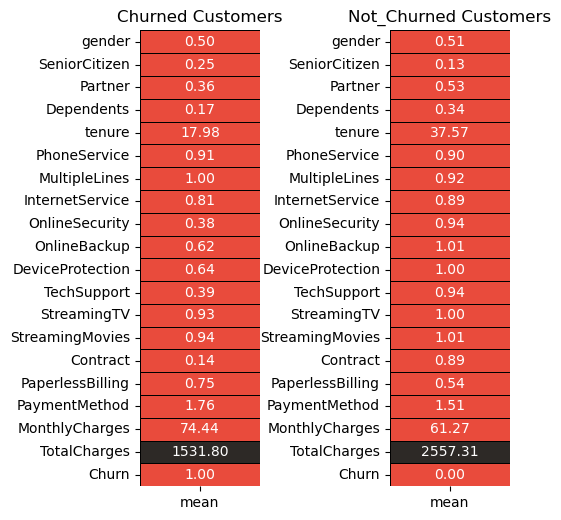

In [15]:
# 헥스 코드로 컬러리스트 생성
colors = ['#E94B3C','#2D2926']

# churn : 이탈함, not_churn : 이탈하지않음 
# 두 데이터의 기본 통계 정보를 저장
churn = df1[df1['Churn'] == 1].describe().T
not_churn = df1[df1['Churn'] == 0].describe().T

# 시각화
#이탈자 평균과, 이탈하지않음 평균을 항목별로 조회 및 시각화
# mataplotlib와 seaborn을 사용하여 히트맵 그리기
fig,ax = plt.subplots(nrows = 1,ncols = 2,figsize = (5,5)) # 1행 2열짜리 그래프 틀(캔버스) 생성
plt.subplot(1,2,1) # 첫 번째 위치(왼쪽) 그래프를 먼저그리겠다고 지정
sns.heatmap(churn[['mean']],annot = True,cmap = colors,linewidths = 0.4,linecolor = 'black',cbar = False,fmt = '.2f')
plt.title('Churned Customers');
plt.subplot(1,2,2)
sns.heatmap(not_churn[['mean']],annot = True,cmap = colors,linewidths = 0.4,linecolor = 'black',cbar = False,fmt = '.2f',)
plt.title('Not_Churned Customers');

# 파라미터	의미
# churn[['mean']]	히트맵에 사용할 데이터 (DataFrame의 mean 열만 사용)
# annot=True	셀 안에 숫자 값을 표시
# cmap=colors	색상 팔레트 지정 (예: "coolwarm", "viridis", 직접 정의한 colors)
# linewidths=0.4	셀 사이의 선 두께
# linecolor='black'	셀 경계선 색상
# cbar=False	오른쪽의 색상 막대(Color bar) 표시 안 함
# fmt='.2f'	셀 안 숫자 표시 형식: 소수점 둘째 자리까지
# plt.title('Churned Customers') 해당 그래프 제목
# ;
    # Jupyter Notebook 같은 환경에서는 아래에 'Text(0.5, 1.0, 'Churned Customers')'
    # 저런 식으로 텍스트 객체 정보가 자동으로 출력된다.
    # 이를 방지하기 위한 명령어(기호)

fig.tight_layout(pad = 0)
# 여러 그래프(subplot) 을 그렸을 때
# 제목, 축 이름, 눈금(label) 등이 겹치지 않도록
# figure 안에서 자동으로 간격을 조정
# pad=0
    # 그래프 사이 여백을 최소화(거의 없게)
    # 기본값은 보통 pad=1.08
    # pad 값이 높을수록 여백이 커진다.
    # pad 값을 너무 크게 잡으면 subplot 영역이 figure 크기를 넘어가면서 겹치거나 잘리는 현상이 발생할 수 있다. 예시 ) 여기서는 pad=10

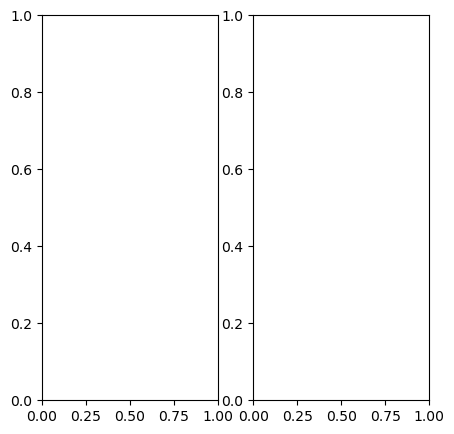

In [16]:
fig,ax = plt.subplots(nrows = 1,ncols = 2,figsize = (5,5))

In [ ]:
# df1의 열 리스트를 저장
col = list(df1.columns)

# 범주형 데이터, 수치형 데이터 열 이름명을 저장할 빈리스트들 생성
categorical_features = []
numerical_features = []

# 추가 #
# 범주형 데이터 열 중에서 고유값 갯수와 해당되는 컬럼명 조회
def text_data_features_unique_counts(text_data_features):
    text_data_features_unique_counts = []
    for index, value in enumerate(text_data_features):
        max_count = text_data_features_unique_counts.append(df1[text_data_features[index]].nunique())
        max_col = 
    print(f'df1 데이터 프레임에서 범주형 데이터, 최대 고유값 갯수 : {max_count}\n해당 범주형 데이터 컬럼명 :{max_col}')

text_data_features_unique_counts(text_data_features)

# 고유값 갯수 조회방법
# data['열이름'].nunique()
# len(data['열이름'].unique())
# len(data['열이름'].value_counts())

# 행을 조회하고싶다면 iloc, loc로 행 인덱스나, 행명을 입력하면 된다.
# print(data.iloc[1].nunique())
# print(data.loc['row1'].nunique())

#
for i in col:
    if len(data[i].unique()) > 6:
        numerical_features.append(i)
    else:
        categorical_features.append(i)

print('Categorical Features :',*categorical_features)
print('Numerical Features :',*numerical_features)

4
Categorical Features : gender SeniorCitizen Partner Dependents PhoneService MultipleLines InternetService OnlineSecurity OnlineBackup DeviceProtection TechSupport StreamingTV StreamingMovies Contract PaperlessBilling PaymentMethod Churn
Numerical Features : tenure MonthlyCharges TotalCharges
